### **IMPORT LIBRARY**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# DEEP LEARNING
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### **LOAD DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/DATASET_UASDL/Combined Data.csv"

'/content/drive/MyDrive/DATASET_UASDL/Combined Data.csv'


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DATASET_UASDL/Combined Data.csv', encoding='ISO-8859-1')

In [ ]:
print("INFO DATA")
df.info()
print("\nJUMLAH DATA:", df.shape)

INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB

JUMLAH DATA: (53043, 3)


### **CEK STRUKTUR DAN KONDISI DATA**

In [ ]:
df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously Iâve (24M) dealt w...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [ ]:
print("5 DATA PERTAMA")
print(df.head())

5 DATA PERTAMA
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [ ]:
print("5 DATA TERAKHIR")
print(df.tail())

5 DATA TERAKHIR
       Unnamed: 0                                          statement   status
53038       53038  Nobody takes me seriously Iâve (24M) dealt w...  Anxiety
53039       53039  selfishness  "I don't feel very good, it's lik...  Anxiety
53040       53040  Is there any way to sleep better? I can't slee...  Anxiety
53041       53041  Public speaking tips? Hi, all. I have to give ...  Anxiety
53042       53042  I have really bad door anxiety! It's not about...  Anxiety


In [ ]:
# CEK KOLOM NUMERIK INDEKS OTOMATIS
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# CEK 'MISSING VALUES' DAN 'DUPLIKAT'
print("MISSING VALUES:")
print(df.isnull().sum())
print(f"\nJUMLAH DUPLIKAT: {df.duplicated().sum()}")

MISSING VALUES:
statement    362
status         0
dtype: int64

JUMLAH DUPLIKAT: 1944


In [ ]:
# Pastikan 'statement' adalah tipe string dan tangani nilai NaN jika ada
# .astype(str) akan mengubah NaN menjadi string "nan"
df['panjang_teks'] = df['statement'].astype(str).str.len()

# --- 2. Menampilkan Teks Paling Panjang ---
print("📊 TEKS PALING PANJANG")
# Dapatkan indeks baris (loc) dari teks terpanjang
idx_terpanjang = df['panjang_teks'].idxmax()

# Ambil data baris lengkap menggunakan .loc
data_terpanjang = df.loc[idx_terpanjang]

print(f"Lokasi (Index): {idx_terpanjang}")
print(f"Panjang Teks: {data_terpanjang['panjang_teks']} karakter")
print(f"Status: {data_terpanjang['status']}")
print(f"Teks: {data_terpanjang['statement']}")
print("\n" + "="*30 + "\n")


# --- 3. Menampilkan Teks Paling Pendek ---
print("📉 TEKS PALING PENDEK")
# Dapatkan indeks baris (loc) dari teks terpendek
idx_terpendek = df['panjang_teks'].idxmin()

# Ambil data baris lengkap menggunakan .loc
data_terpendek = df.loc[idx_terpendek]

print(f"Lokasi (Index): {idx_terpendek}")
print(f"Panjang Teks: {data_terpendek['panjang_teks']} karakter")
print(f"Status: {data_terpendek['status']}")
print(f"Teks: {data_terpendek['statement']}")

📊 TEKS PALING PANJANG
Lokasi (Index): 13293
Panjang Teks: 32759 karakter
Status: Suicidal
Teks: I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANYMORE. I cannot TAKE IT ANY

### **EKSPLORASI DATA/EDA**

DISTRIBUSI KELAS [STATUS]
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


/tmp/ipython-input-4034635132.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


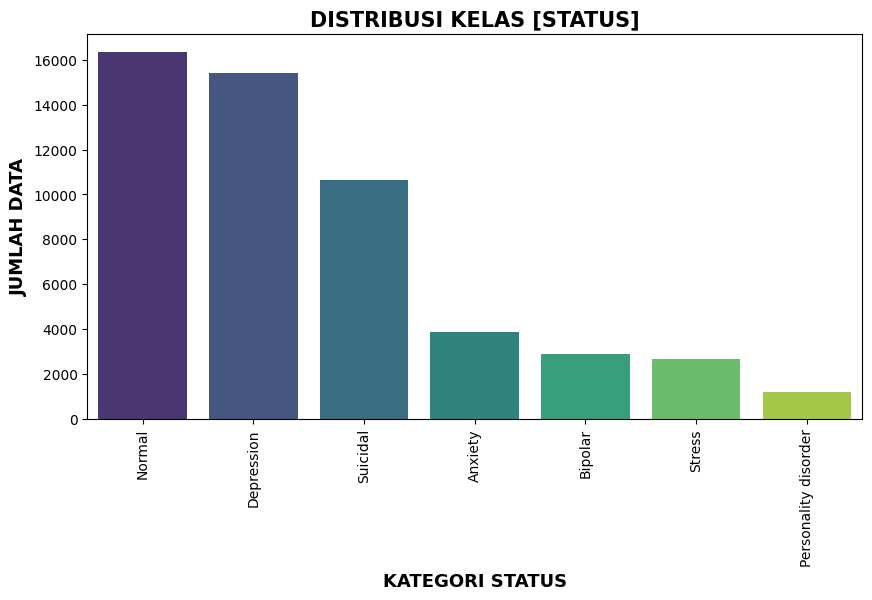

In [ ]:
## DISTRIBUSI KELAS [STATUS]
print("DISTRIBUSI KELAS [STATUS]")
class_counts = df['status'].value_counts()
print(class_counts)

plt.figure(figsize=(10,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title("DISTRIBUSI KELAS [STATUS]", fontsize=15, fontweight='bold')
plt.xlabel("KATEGORI STATUS", fontsize=13, fontweight='bold')
plt.ylabel("JUMLAH DATA", fontsize=13, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

In [ ]:
## CEK 'MISSING VALUE' DI KOLOM STATEMENT
missing_statement = df['statement'].isnull().sum()
print(f"JUMLAH NILAI KOSONG PADA KOLOM 'statement': {missing_statement}")

JUMLAH NILAI KOSONG PADA KOLOM 'statement': 362



STATISTIK PANJANG TEKS
        text_length    word_count
count  53043.000000  53043.000000
mean     576.151971    112.394661
std      845.791375    163.437809
min        2.000000      1.000000
25%       78.000000     15.000000
50%      313.000000     61.000000
75%      751.000000    147.500000
max    32759.000000   6300.000000


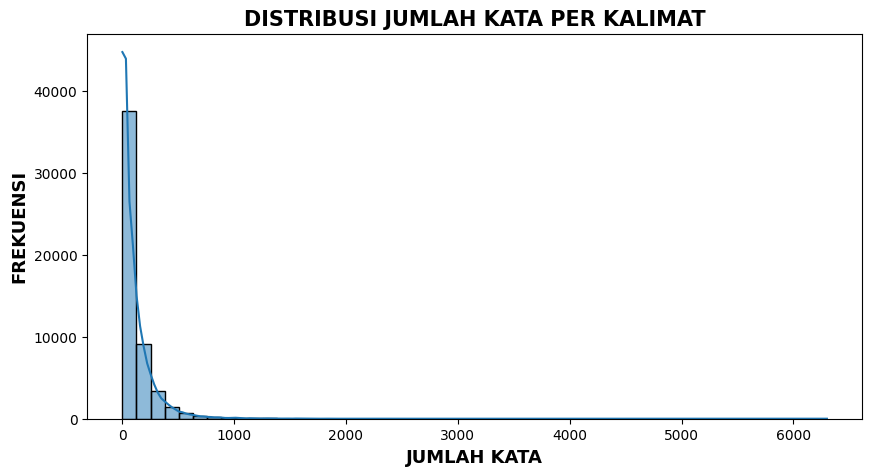

In [ ]:
## PANJANG TEKS [DALAM KARAKTER DAN KATA]
df['statement']   = df['statement'].astype(str)
df["text_length"] = df["statement"].apply(len)
df["word_count"]  = df["statement"].apply(lambda x: len(x.split()))

print("\nSTATISTIK PANJANG TEKS")
print(df[["text_length", "word_count"]].describe())

plt.figure(figsize=(10,5))
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("DISTRIBUSI JUMLAH KATA PER KALIMAT", fontsize=15, fontweight='bold')
plt.xlabel("JUMLAH KATA", fontsize=13, fontweight='bold')
plt.ylabel("FREKUENSI", fontsize=13, fontweight='bold')
plt.show()


In [ ]:
## 20 KATA SERING MUNCUL
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

cleaned_words = " ".join(df["statement"].apply(basic_clean)).split()
word_freq    = Counter(cleaned_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=["Kata", "Frekuensi"])
print("\n20 KATA PALING SERING MUNCUL")
print(common_words)


20 KATA PALING SERING MUNCUL
    Kata  Frekuensi
0      i     401558
1     to     197461
2    and     175495
3    the     126762
4     my     119460
5      a     117751
6     it      86324
7     of      84899
8    not      76291
9     me      72314
10    is      72227
11  have      69897
12  that      67996
13    am      62812
14    in      61806
15   but      56387
16    do      55789
17   for      54553
18  just      48823
19  this      47277


### **DATA PREPROCESSING**

In [ ]:
## HAPUS MISSING VALUE DAN DUPLIKAT DATA
df.dropna(subset=['statement'], inplace=True)
df.drop_duplicates(subset=['statement'], inplace=True)
print(f"DATA SETELAH HAPUS NaN DAN DUPLIKAT: {df.shape}")

DATA SETELAH HAPUS NaN DAN DUPLIKAT: (51074, 5)


In [ ]:
## TEXT CLEANING
def clean_text(text):
    text = text.lower()                                # NORMALISASI HURUF
    text = re.sub(r'http\S+|www\S+', '', text)         # HAPUS URL
    text = re.sub(r'@\w+', '', text)                   # HAPUS MENTION
    text = re.sub(r'[^a-z\s]', '', text)               # HAPUS SIMBOL/ANGKA
    text = re.sub(r'\s+', ' ', text).strip()           # HAPUS SPASI GANDA
    return text

df['clean_text'] = df['statement'].apply(clean_text)

In [ ]:
# 5 BARIS PERTAMA HASIL TEXT CLEANING
df[['statement', 'clean_text']].head()

,statement,clean_text
0,oh my gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...
4,"I'm restless and restless, it's been a month n...",im restless and restless its been a month now ...


In [ ]:
# 5 BARIS TERAKHIR HASIL TEXT CLEANING
df[['statement', 'clean_text']].tail()

,statement,clean_text
52835,Anxiety cause faintness when standing up ? As ...,anxiety cause faintness when standing up as ti...
52836,anxiety heart symptom does anyone else have th...,anxiety heart symptom does anyone else have th...
52837,Travel Anxiety Hi all! Long time anxiety suffe...,travel anxiety hi all long time anxiety suffer...
52839,fomo from things iâm not involved in does an...,fomo from things im not involved in does anyon...
52840,Getting through the day How do you get anythi...,getting through the day how do you get anythin...


In [ ]:
print("HASIL TEXT CLEANING [5 BARIS ACAK]:")
print(df[['statement', 'clean_text']].sample(5, random_state=42))

HASIL TEXT CLEANING [5 BARIS ACAK]:
                                               statement  \
33805             he's been a chain smoker for 30 years.   
16252  Hoards of people walking or zipping by on scoo...   
12136  i cannot win in my life, no matter how hard i ...   
51944  Am I being too hard on myself? I'm putting mys...   
47393  Disassociation Can please anyone help me I fee...   

                                              clean_text  
33805                  hes been a chain smoker for years  
16252  hoards of people walking or zipping by on scoo...  
12136  i cannot win in my life no matter how hard i t...  
51944  am i being too hard on myself im putting mysel...  
47393  disassociation can please anyone help me i fee...  


In [ ]:
# CEK PERUBAHAN PANJANG TEKS SEBELUM DAN SESUDAH TEXT CLEANING

df['before_len'] = df['statement'].apply(lambda x: len(str(x)))
df['after_len']  = df['clean_text'].apply(lambda x: len(str(x)))
df[['before_len', 'after_len']].describe()

,before_len,after_len
count,51074.000000,51074.000000
mean,576.610487,558.100736
std,848.599900,824.720179
min,2.000000,0.000000
25%,80.000000,75.000000
50%,313.000000,302.000000
75%,747.000000,724.000000
max,32759.000000,31499.000000


In [ ]:
## STOPWORD REMOVAL

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# SIMPAN VERSI SEBELUM STOPWORD REMOVAL
df['before_stopword'] = df['clean_text']

# HAPUS STOPWORDS
df['clean_text'] = df['clean_text'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print("HASIL STOPWORD REMOVAL [5 BARIS ACAK]:")
print(df[['before_stopword', 'clean_text']].sample(5, random_state=42))

HASIL STOPWORD REMOVAL [5 BARIS ACAK]:
                                         before_stopword  \
33805                  hes been a chain smoker for years   
16252  hoards of people walking or zipping by on scoo...   
12136  i cannot win in my life no matter how hard i t...   
51944  am i being too hard on myself im putting mysel...   
47393  disassociation can please anyone help me i fee...   

                                              clean_text  
33805                             hes chain smoker years  
16252  hoards people walking zipping scooters going n...  
12136  cannot win life matter hard try cannot ever se...  
51944  hard im putting university undergraduate degre...  
47393  disassociation please anyone help feel bad lik...  


In [ ]:
print("5 BARIS PERTAMA HASIL STOPWORD REMOVAL:")
print(df[['before_stopword', 'clean_text']].head())

5 BARIS PERTAMA HASIL STOPWORD REMOVAL:
                                     before_stopword  \
0                                         oh my gosh   
1  trouble sleeping confused mind restless heart ...   
2  all wrong back off dear forward doubt stay in ...   
3  ive shifted my focus to something else but im ...   
4  im restless and restless its been a month now ...   

                                          clean_text  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  


In [ ]:
print("5 BARIS TERAKHIR HASIL STOPWORD REMOVAL:")
print(df[['before_stopword', 'clean_text']].tail())

5 BARIS TERAKHIR HASIL STOPWORD REMOVAL:
                                         before_stopword  \
52835  anxiety cause faintness when standing up as ti...   
52836  anxiety heart symptom does anyone else have th...   
52837  travel anxiety hi all long time anxiety suffer...   
52839  fomo from things im not involved in does anyon...   
52840  getting through the day how do you get anythin...   

                                              clean_text  
52835  anxiety cause faintness standing title anxiety...  
52836  anxiety heart symptom anyone else something si...  
52837  travel anxiety hi long time anxiety sufferer f...  
52839  fomo things im involved anyone else get recent...  
52840  getting day get anything done anxiety keep hou...  


In [ ]:
# CEK PERUBAHAN PANJANG TEKS SEBELUM DAN SESUDAH STOPWORD REMOVAL

df['before_len'] = df['before_stopword'].apply(lambda x: len(str(x)))
df['after_len']  = df['clean_text'].apply(lambda x: len(str(x)))

In [ ]:
print("PERBANDINGAN PANJANG TEKS [SEBELUM DAN SESUDAH STOPWORD REMOVAL:")
print(df[['before_len', 'after_len']].describe())

print("\nRATA-RATA PENGURANGAN PANJANG TEKS:",
      round(df['before_len'].mean() - df['after_len'].mean(), 2))

PERBANDINGAN PANJANG TEKS [SEBELUM DAN SESUDAH STOPWORD REMOVAL:
         before_len     after_len
count  51074.000000  51074.000000
mean     558.100736    337.909465
std      824.720179    509.062092
min        0.000000      0.000000
25%       75.000000     49.000000
50%      302.000000    184.000000
75%      724.000000    436.000000
max    31499.000000  25289.000000

RATA-RATA PENGURANGAN PANJANG TEKS: 220.19


In [ ]:
## LEMMATIZATION
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
df['clean_text'] = df['clean_text'].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
print("HASIL LEMMATIZATION:")
print(df[['clean_text']].sample(5, random_state=42))

HASIL LEMMATIZATION:
                                              clean_text
33805                               he chain smoker year
16252  hoard people walking zipping scooter going now...
12136  cannot win life matter hard try cannot ever se...
51944  hard im putting university undergraduate degre...
47393  disassociation please anyone help feel bad lik...


In [ ]:
## LABEL ENCODING
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

In [ ]:
print("\nMAPPING LABEL:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

print("\nDISTRIBUSI LABEL:")
print(df['label'].value_counts())


MAPPING LABEL:
{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}

DISTRIBUSI LABEL:
label
3    16039
2    15087
6    10641
0     3618
1     2501
5     2293
4      895
Name: count, dtype: int64


In [ ]:
print("Menerapkan text cleaning...")
df['clean_text'] = df['statement'].apply(clean_text)

df['clean_text_outlierout'] = df['clean_text'].str.len()

Menerapkan text cleaning...


In [ ]:
# Tampilkan 5 baris pertama HANYA untuk kolom-kolom ini
print(df[['statement', 'clean_text', 'clean_text_outlierout']].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                          clean_text  clean_text_outlierout  
0                                         oh my gosh                     10  
1  trouble sleeping confused mind restless heart ...                     61  
2  all wrong back off dear forward doubt stay in ...                     75  
3  ive shifted my focus to something else but im ...                     59  
4  im restless and restless its been a month now ...                     66  


In [ ]:
# Tentukan batas panjang teks yang Anda anggap wajar
panjang_min = 10     # Membuang teks "lw" (panjang 2) dan noise lainnya
panjang_max = 3000   # Membuang teks spam (panjang 32.759)

jumlah_awal = len(df)
print(f"Jumlah data sebelum difilter: {jumlah_awal}")

df_filtered = df[df['clean_text_outlierout'].between(panjang_min, panjang_max)].copy()

# -------------------------------------------------------------------

# Cek hasilnya
jumlah_akhir = len(df_filtered)
print(f"Jumlah data setelah difilter (outlier dibuang): {jumlah_akhir}")
print(f"Total data yang dihapus: {jumlah_awal - jumlah_akhir}")

# Menampilkan 5 data pertama dari DataFrame baru yang sudah bersih
print("\nData teratas dari df_filtered (siap diproses):")
print(df_filtered.head())

Jumlah data sebelum difilter: 51074
Jumlah data setelah difilter (outlier dibuang): 49703
Total data yang dihapus: 1371

Data teratas dari df_filtered (siap diproses):
                                           statement   status  panjang_teks  \
0                                         oh my gosh  Anxiety            10   
1  trouble sleeping, confused mind, restless hear...  Anxiety            64   
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety            78   
3  I've shifted my focus to something else but I'...  Anxiety            61   
4  I'm restless and restless, it's been a month n...  Anxiety            72   

   text_length  word_count                                         clean_text  \
0           10           3                                         oh my gosh   
1           64          10  trouble sleeping confused mind restless heart ...   
2           78          14  all wrong back off dear forward doubt stay in ...   
3           61          11  ive s

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- 1. Ambil X dan y dari DataFrame yang SUDAH DIFILTER ---
# Pastikan menggunakan 'clean_text' (yang sudah bersih)
X_texts = df_filtered['clean_text'].astype(str)

# Pastikan menggunakan 'status' (kolom label asli Anda)
y_labels = df_filtered['status'].astype(str)

print(f"Menggunakan {len(X_texts)} sampel yang sudah difilter untuk diproses.")

# --- 2. Parameter Tokenizer (Sesuai setelan Anda) ---
max_words = 10000
max_len = 100

# --- 3. Proses X (Tokenisasi & Padding) ---
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_texts)

sequences = tokenizer.texts_to_sequences(X_texts)
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print("Tokenisasi dan Padding X selesai.")

# --- 4. Proses y (Label Encoding) ---
# Mengubah label teks (cth: 'Anxiety', 'Normal') menjadi angka (cth: 0, 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

# Simpan jumlah kelas untuk layer output model
NUM_CLASSES = len(le.classes_)

print("Label Encoding y selesai.")

# --- 5. Cek Final (PENTING) ---
# Cek ini untuk memastikan split Anda tidak akan error
print("\n--- HASIL PREPROCESSING ---")
print(f"Bentuk X_padded (Data Teks): {X_padded.shape}")
print(f"Bentuk y_encoded (Label): {y_encoded.shape}")
print(f"Total Kelas Ditemukan: {NUM_CLASSES}")

if X_padded.shape[0] == y_encoded.shape[0]:
    print("STATUS: OK! Jumlah X dan y SAMA. Siap untuk di-split.")
else:
    print("STATUS: ERROR! Jumlah X dan y TIDAK SAMA. Periksa kode.")

Menggunakan 49703 sampel yang sudah difilter untuk diproses.
Tokenisasi dan Padding X selesai.
Label Encoding y selesai.

--- HASIL PREPROCESSING ---
Bentuk X_padded (Data Teks): (49703, 100)
Bentuk y_encoded (Label): (49703,)
Total Kelas Ditemukan: 7
STATUS: OK! Jumlah X dan y SAMA. Siap untuk di-split.


In [ ]:
!pip install nlpaug

In [ ]:
import nlpaug.augmenter.word as naw
import nltk
import pandas as pd
import numpy as np
from collections import Counter

# Download 'wordnet' (kamus sinonim) dan 'tagger'
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
## AUGMENTASI MINORITAS
aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.1)

# Tentukan kelas yang mau di-augmentasi
kelas_minoritas = ['Anxiety', 'Bipolar', 'Stress', 'Personality disorder']

# Download resource NLTK yang spesifik untuk nlpaug
nltk.download('averaged_perceptron_tagger_eng')

# List untuk menampung data baru
df_augmented_list = []

# Loop untuk setiap kelas minoritas
for kelas in kelas_minoritas:
    # Ambil semua teks dari kelas itu
    df_kelas = df_filtered[df_filtered['status'] == kelas]

    print(f"Meng-augmentasi {len(df_kelas)} sampel untuk kelas: {kelas}")

    # Buat 1 teks baru (n=1) untuk setiap teks asli
    for text in df_kelas['clean_text']:
        # aug.augment() mengembalikan list, ambil elemen pertama [0]
        augmented_text = aug.augment(text, n=1)[0]
        df_augmented_list.append({
            'clean_text': augmented_text,
            'status': kelas # Labelnya tetap sama
        })

# Ubah list data baru menjadi DataFrame
df_augmented = pd.DataFrame(df_augmented_list)

# Gabungkan data asli (df_filtered) dengan data baru (df_augmented)
df_final = pd.concat([df_filtered, df_augmented], ignore_index=True)

print(f"\nData asli (df_filtered): {len(df_filtered)}")
print(f"Data baru hasil augmentasi: {len(df_augmented)}")
print(f"Total data (df_final): {len(df_final)}\n")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Meng-augmentasi 3535 sampel untuk kelas: Anxiety
Meng-augmentasi 2436 sampel untuk kelas: Bipolar
Meng-augmentasi 2277 sampel untuk kelas: Stress
Meng-augmentasi 870 sampel untuk kelas: Personality disorder

Data asli (df_filtered): 49703
Data baru hasil augmentasi: 9118
Total data (df_final): 58821



In [ ]:
print("Distribusi Kelas Setelah Augmentasi (Gabungan):")
print(df_final['status'].value_counts())

Distribusi Kelas Setelah Augmentasi (Gabungan):
status
Normal                  15574
Depression              14640
Suicidal                10371
Anxiety                  7070
Bipolar                  4872
Stress                   4554
Personality disorder     1740
Name: count, dtype: int64


In [ ]:
##TOKENISASI

# Ambil X dan y dari 'df_final' (yang sudah digabung)
X_texts = df_final['clean_text'].astype(str)
y_labels = df_final['status'].astype(str)

max_words = 10000
max_len = 100

# Tokenisasi X
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_texts)
sequences = tokenizer.texts_to_sequences(X_texts)
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Encoding y
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
NUM_CLASSES = len(le.classes_)

print(f"Bentuk X (padded): {X_padded.shape}")
print(f"Bentuk y (encoded): {y_encoded.shape}\n")

Bentuk X (padded): (58821, 100)
Bentuk y (encoded): (58821,)



In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(set(y_train))

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

### **HANDLING CLASS IMBALANCE**

##WITH CLASS WEIGHT

split data train dan test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Menjaga proporsi kelas
)

class weight digunakan, namun dia tidak mengubah data cmn model diperuntukkan lebih dalam ke kelas yg minoritas jadi auto dr model yg mengolah bkn dr kita

In [ ]:
import numpy as np
from sklearn.utils import class_weight

# Cari kelas unik yang ada di data training
classes = np.unique(y_train)

# Hitung bobot agar setiap kelas punya pengaruh seimbang
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Ubah ke format dictionary {kelas: bobot} yang diminta Keras
class_weights_dict = dict(zip(classes, weights))

print("Bobot Kelas:", class_weights_dict)
# Output akan menunjukkan bobot > 1 untuk kelas minoritas (seperti kelas 4)
# dan bobot < 1 untuk kelas mayoritas (seperti kelas 3).

Bobot Kelas: {np.int64(0): np.float64(1.1885229339260457), np.int64(1): np.float64(1.7249899189853), np.int64(2): np.float64(0.5739656518345043), np.int64(3): np.float64(0.539552589636866), np.int64(4): np.float64(4.829228243021347), np.int64(5): np.float64(1.845260970158033), np.int64(6): np.float64(0.810206787306944)}


## **MODEL SELECTION N HYPERPARAMETER**

base model

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.6 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definisi fungsi build_model untuk KerasTuner
def build_model(hp):
    model = Sequential()
    model.add(Embedding(
        input_dim=max_words,
        output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32)
    ))

    model.add(LSTM(
        units=hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    ))
    # -------------------

    model.add(Dropout(
        hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    ))
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer=Adam(hp.Float('learning_rate', min_value=0.0005, max_value=0.001, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Inisialisasi Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='sentiment_tuning_fixed' # Nama project baru agar tidak bentrok
)

# Menampilkan ringkasan search space
tuner.search_space_summary()

Search space summary
Default search space size: 4
embedding_dim (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
lstm_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0005, 'conditions': [], 'min_value': 0.0005, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


hyperparameter tuning

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Kita akan menggunakan y_train_cat dan y_test_cat yang sudah dibuat di sel 25.

print("Data shape yang akan digunakan:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")
print("\nBobot Kelas yang digunakan:")
print(class_weights_dict)

# Membuat callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Memantau validation loss
    patience=3,          # Berhenti jika tidak ada perbaikan setelah 3 epoch
    restore_best_weights=True # Mengembalikan bobot model terbaik
)

print("\nMemulai pencarian hyperparameter...")
# --- PERBAIKAN ---
# Menggunakan validation_split=0.2
# Ini akan otomatis mengambil 20% dari X_train & y_train_cat untuk validasi
tuner.search(
    X_train, y_train_cat,
    epochs=10,
    validation_split=0.20,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

# Mendapatkan hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nHyperparameter Terbaik Ditemukan:")
print(f"Embedding Dim: {best_hps.get('embedding_dim')}")
print(f"LSTM Units: {best_hps.get('lstm_units')}")
print(f"Dropout Rate: {best_hps.get('dropout_rate')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

# Mendapatkan model terbaik
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

# Evaluasi model terbaik pada data test
print("\nMengevaluasi model terbaik pada data test...")
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

Trial 10 Complete [00h 01m 55s]
val_accuracy: 0.777305543422699

Best val_accuracy So Far: 0.783255398273468
Total elapsed time: 00h 20m 58s

Hyperparameter Terbaik Ditemukan:
Embedding Dim: 128
LSTM Units: 96
Dropout Rate: 0.2
Learning Rate: 0.0007109563513642855


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 96)             │        86,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,367,079 (5.21 MB)

 Trainable params: 1,367,079 (5.21 MB)

 Non-trainable params: 0 (0.00 B)


Mengevaluasi model terbaik pada data test...
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7846 - loss: 0.6361

Test Loss: 0.6519217491149902
Test Accuracy: 0.7793455123901367


## **MODEL EVALUATION**

In [ ]:
# prediksi
y_pred_proba = best_model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# akurasi
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")


368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.7793


In [ ]:
# classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))


Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.87      0.87      0.87      1414
             Bipolar       0.84      0.85      0.85       975
          Depression       0.70      0.67      0.69      2928
              Normal       0.94      0.89      0.91      3115
Personality disorder       0.68      0.79      0.73       348
              Stress       0.69      0.79      0.74       911
            Suicidal       0.64      0.66      0.65      2074

            accuracy                           0.78     11765
           macro avg       0.77      0.79      0.78     11765
        weighted avg       0.78      0.78      0.78     11765



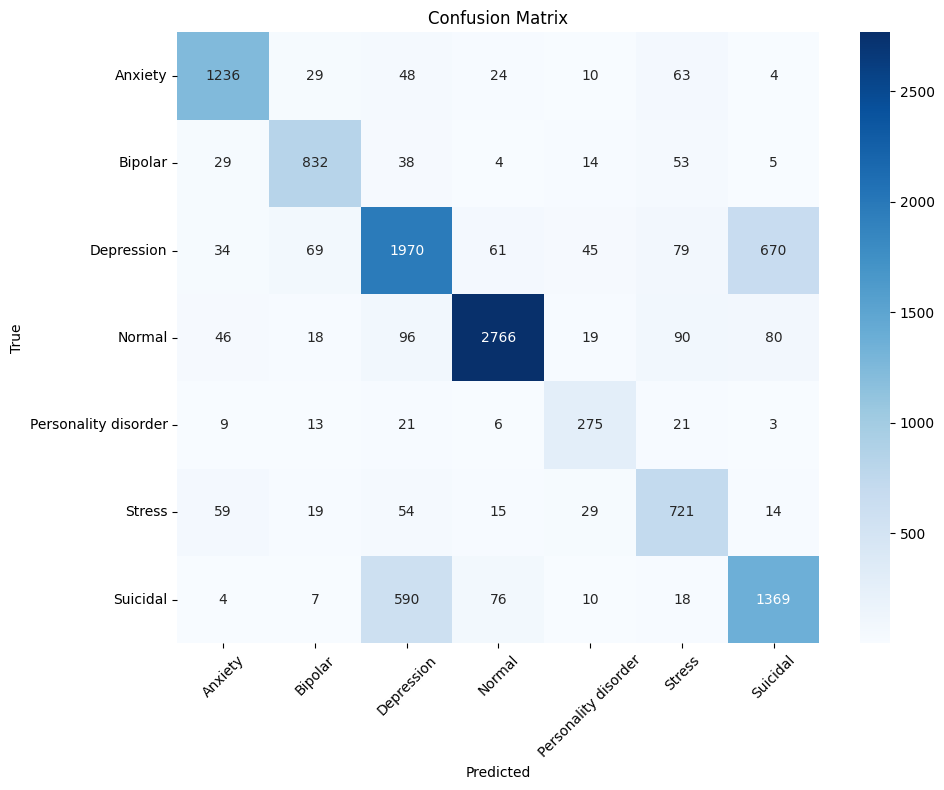

In [ ]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Akurasi Per Kelas:
Anxiety: 0.8741
Bipolar: 0.8533
Depression: 0.6728
Normal: 0.8880
Personality disorder: 0.7902
Stress: 0.7914
Suicidal: 0.6601


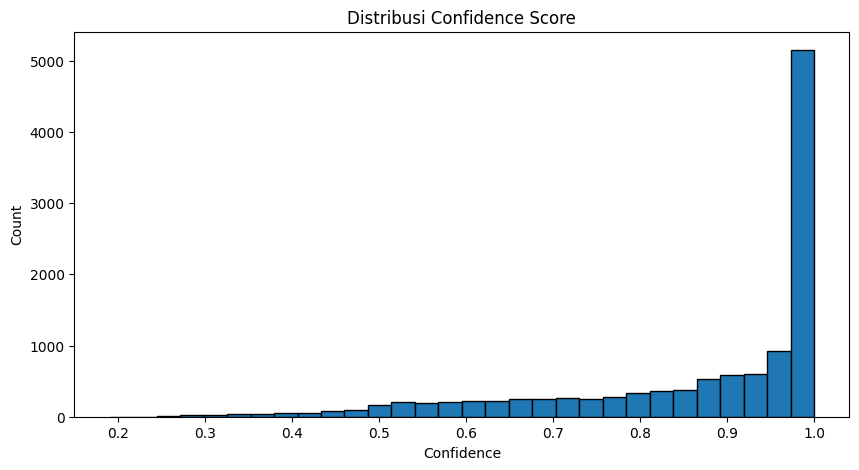

In [ ]:
# evaluasi per kelas
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nAkurasi Per Kelas:")
for i, name in enumerate(le.classes_):
    print(f"{name}: {per_class_acc[i]:.4f}")

# distribusi confidence
confidence = np.max(y_pred_proba, axis=1)
plt.figure(figsize=(10,5))
plt.hist(confidence, bins=30, edgecolor='black')
plt.title('Distribusi Confidence Score')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.show()

In [ ]:
def preprocess_new(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = " ".join([word for word in text.split() if word not in stop_words])
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])
    return text

def predict(text):
    cleaned = preprocess_new(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = best_model.predict(padded, verbose=0)
    label = le.classes_[np.argmax(pred)]
    conf = np.max(pred)

    print(f"\n{text}")
    print(f"{label}\n")
    return label

In [ ]:
# test prediksi
predict("I feel constantly overwhelmed and anxious")


I feel constantly overwhelmed and anxious
Anxiety



'Anxiety'

In [ ]:
predict("I am feeling great today and everything is wonderful")


I am feeling great today and everything is wonderful
Normal



'Normal'

In [ ]:
predict("I can't stop crying and feel hopeless about everything")


I can't stop crying and feel hopeless about everything
Bipolar



'Bipolar'

In [ ]:
predict("Life has no meaning anymore")


Life has no meaning anymore
Suicidal



'Suicidal'

In [ ]:
predict("36 hours since eat drank anything really hungr")
##ini salah predictnya harusnya suicidal


36 hours since eat drank anything really hungr
Normal



'Normal'